In [1]:
# ===== Lesson 9: Quality Control (QC) in Scanpy =====

# 1. Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Define project paths with pathlib
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/scRNA_project")
LESSON = PROJECT / "lesson09"

CODE = LESSON / "code"
NOTES = LESSON / "notes"
OUTPUT = LESSON / "output"

# 3. Create this lesson's folders
for folder in [CODE, NOTES, OUTPUT]:
    folder.mkdir(parents=True, exist_ok=True)
    print("Ready:", folder)

# 4. Install & import Scanpy, NumPy, Pandas, Matplotlib + load PBMC-3k
!pip install scanpy -q
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata = sc.datasets.pbmc3k()

Mounted at /content/drive
Ready: /content/drive/MyDrive/scRNA_project/lesson09/code
Ready: /content/drive/MyDrive/scRNA_project/lesson09/notes
Ready: /content/drive/MyDrive/scRNA_project/lesson09/output
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages t

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

In [2]:
# 5. Mark mitochondrial genes in adata.var
adata.var['mt'] = adata.var_names.str.startswith('MT-')
print(adata.var['mt'].sum())

13


In [3]:
# 6. Run Scanpy's official QC metric calculation
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(adata.obs.columns.tolist())
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].head())

['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']
                  n_genes_by_counts  total_counts  pct_counts_mt
index                                                           
AAACATACAACCAC-1                781        2421.0       3.015283
AAACATTGAGCTAC-1               1352        4903.0       3.793596
AAACATTGATCAGC-1               1131        3149.0       0.889171
AAACCGTGCTTCCG-1                960        2639.0       1.743085
AAACCGTGTATGCG-1                522         981.0       1.223242


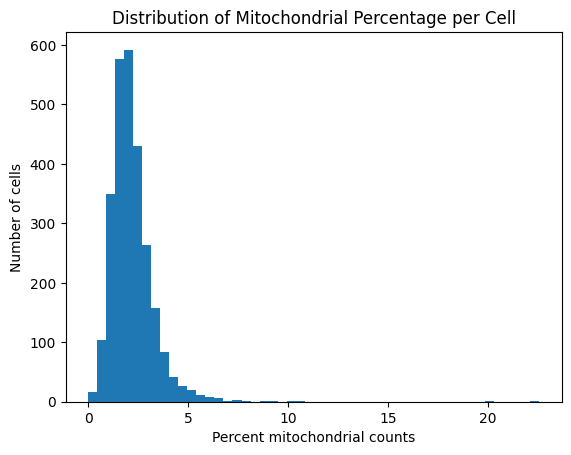

count    2700.000000
mean        2.215132
std         1.165438
min         0.000000
25%         1.536238
50%         2.029639
75%         2.640218
max        22.569027
Name: pct_counts_mt, dtype: float64


In [4]:
# 7. Look at the distribution of pct_counts_mt
plt.hist(adata.obs['pct_counts_mt'], bins=50)
plt.title("Distribution of Mitochondrial Percentage per Cell")
plt.xlabel("Percent mitochondrial counts")
plt.ylabel("Number of cells")
plt.show()

print(adata.obs['pct_counts_mt'].describe())

In [5]:
# 8. Filtering: remove low-quality cells and rarely-detected genes
print("Before filtering:", adata.shape)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs['pct_counts_mt'] < 5, :].copy()

print("After filtering:", adata.shape)

Before filtering: (2700, 32738)
After filtering: (2643, 13714)


In [6]:
# 9. Final check
print("Final cell count:", adata.n_obs)
print("Final gene count:", adata.n_vars)

Final cell count: 2643
Final gene count: 13714
